<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_3/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_3_%D0%9E%D0%B1%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%B5%D1%81%D1%82%D0%B5%D1%81%D1%82%D0%B2%D0%B5%D0%BD%D0%BD%D0%BE%D0%B3%D0%BE_%D1%8F%D0%B7%D1%8B%D0%BA%D0%B0_%D0%BE%D1%82_%D1%82%D0%B5%D0%BA%D1%81%D1%82%D0%B0_%D0%BA_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%B0%D0%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №3: Обработка естественного языка: от текста к признакам

---

## 1. ВВЕДЕНИЕ

Язык — это основной инструмент психотерапии. Мы работаем со словами клиентов ежедневно: слушаем их истории, анализируем дневниковые записи, читаем сообщения в чатах поддержки. Но как превратить этот живой, неструктурированный поток речи в данные, которые можно анализировать количественно?

Современные системы искусственного интеллекта (о которых мы говорили в Лекции 1) анализируют тексты пациентов: измеряют эмоциональный тон, выявляют когнитивные искажения, отслеживают динамику состояния, прогнозируют риски. Обработка естественного языка (Natural Language Processing, NLP) — это мост между живой речью пациента и структурированными данными, которые можно описать статистиками (как мы делали в Лекции 2) и подать на вход моделям машинного обучения.

**Ключевая мысль:** текст пациента — это не просто «слова», это сложный сигнал, содержащий диагностическую информацию. NLP помогает этот сигнал расшифровать, превращая язык в измеримые признаки.

**Этический контекст:** мы должны помнить, что анализ текста — это вторжение в приватность. Пациент может не знать, что его «дневник» анализирует алгоритм. Использование NLP в психологии требует информированного согласия и прозрачности, о чём мы поговорим в заключении и в вопросе для самопроверки.

---

## 2. ПОЧЕМУ ТЕКСТЫ ПАЦИЕНТОВ — ЭТО ВЫЗОВ ДЛЯ КОМПЬЮТЕРА

Тексты, с которыми работает психолог, кардинально отличаются от литературных произведений, новостных статей или научных публикаций. Это создаёт уникальные вызовы для компьютерной обработки. Рассмотрим шесть ключевых особенностей.

**1. Шум и неструктурированность**

Пациенты пишут так, как говорят: с повторами, оговорками, незаконченными предложениями.

> **Пример из дневниковой записи пациента:**  
> *«Я… ну, я не знаю, как это объяснить… Всё, типа, перевернулось у меня внутри, и я, в общем, не могу… не могу я больше так…»*

Для компьютера — это «грязный» текст, где трудно выделить смысловые единицы.

**2. Опечатки и орфографические ошибки**

В быстрой переписке или дневниковой записи люди часто допускают ошибки.

> **Пример из дневника пациента:**  
> *«севодня праснулся и понял што не хочу ничево. ваще не хачу. лежу и сматру в потолок»*

Опечатки могут сбивать алгоритмы, которые ищут точное совпадение слов.

**3. Сленг, аббревиатуры, разговорные формы**

Пациенты используют сокращения («хз» — неизвестно), сленг («триггер», «токсик»), англицизмы («овертонк», «свитч»), подростковый язык.

> **Пример из переписки подростка:**  
> *«он меня опять затриггерил, я в ауте, капец, как же всё задолбало, хочу в тильт»*

Эти формы нужно нормализовать, иначе модель их не узнает.

**4. Эмоционально окрашенная лексика**

Тексты пациентов насыщены словами, выражающими страдание, тревогу, безнадёжность.

> **Пример:**  
> *«Я просто выжженая пустыня. Ничего не чувствую. Зачем я вообще просыпаюсь?»*

Компьютер должен не просто распознать слова, а понять их эмоциональный вес и семантическую нагрузку.

**5. Культурные и возрастные особенности**

Язык подростка отличается от языка пожилого человека. В разных регионах России одно и то же состояние описывают по-разному («тоска» vs «хандра» vs «депрессняк»).

**6. Русский язык — особая сложность**

Свободный порядок слов, богатая морфология, сложное словообразование. Об этом — подробно в разделе 6.

**Визуализация:** схема «Портрет типичного текста пациента» (центральный круг — «Текст пациента», от него шесть лучей с примерами).


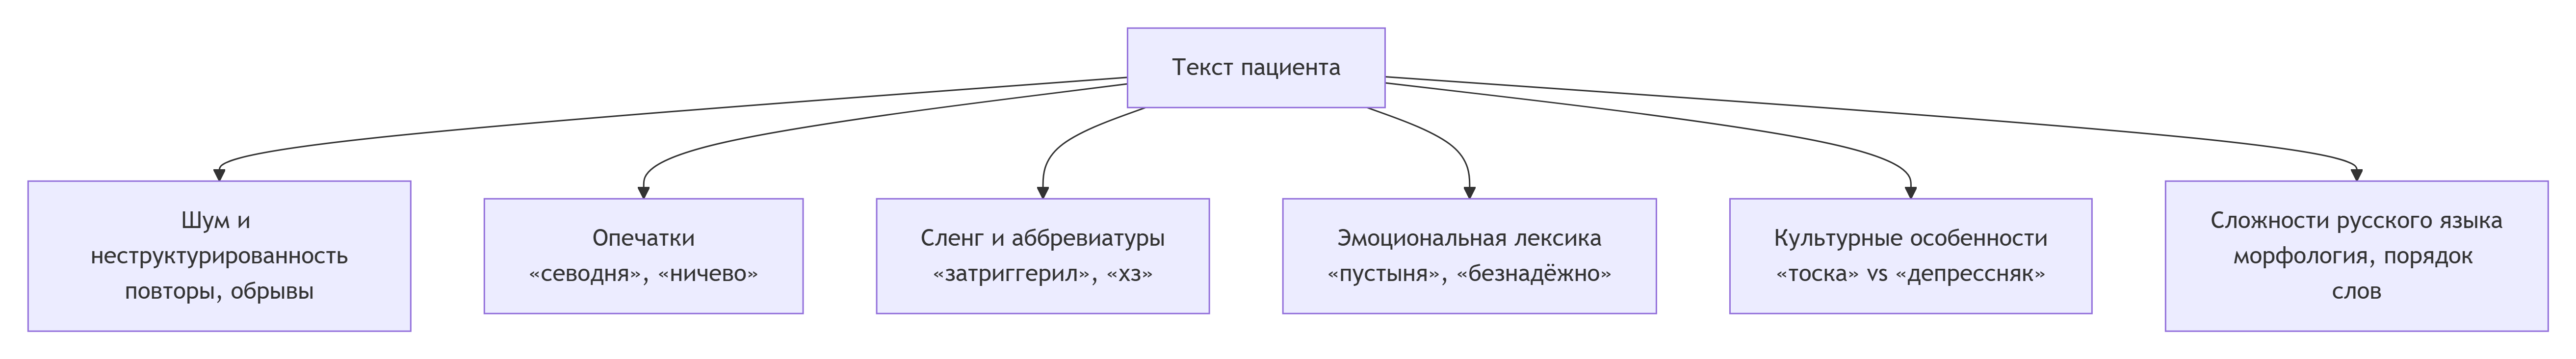




## 3. ЭТАПЫ ОЧИСТКИ ТЕКСТА (ПРЕПРОЦЕССИНГ)

Прежде чем анализировать смысл, текст нужно «причесать». Это как наведение порядка в кабинете перед приёмом пациента — чтобы ничего не отвлекало от главного. Рассмотрим четыре ключевых этапа.

### 3.1. Токенизация (Tokenization)

**Что это:** разбивка текста на минимальные смысловые единицы — **токены** (слова, числа, знаки препинания).

**Пример из психологии:**
- Исходный текст: *«Я сегодня просто не могу. Всё валится из рук.»*
- Токены: `["Я", "сегодня", "просто", "не", "могу", ".", "Всё", "валится", "из", "рук", "."]`

**Почему это важно:** компьютер не понимает текст как непрерывный поток; ему нужны отдельные «кирпичики» для анализа.

**Особенности для русского языка:** нужно правильно обрабатывать знаки препинания и сокращения («т.д.» — не разбивать на «т.» и «д.»). Существуют специальные токенизаторы для русского языка (например, в библиотеке `nltk` или `pymorphy2`) [2], [6].

### 3.2. Удаление стоп-слов (Stop Words Removal)

**Что это:** удаление самых частотных, но малоинформативных слов, которые не несут смысловой нагрузки: предлоги, союзы, частицы, местоимения.

**Пример из психологии:**
- Исходный текст: *«Я не хочу, чтобы ты меня оставлял. Я так боюсь.»*
- Удаляем стоп-слова (`я`, `не`, `чтобы`, `ты`, `меня`, `я`, `так`).
- Остаётся: `["хочу", "оставлял", "боюсь"]` — смысловое ядро.

**Важное предостережение для психолога:**
Слово **«не»** — это стандартное стоп-слово, но в клиническом контексте оно является маркером негативного мышления, когнитивных искажений («не хочу жить», «не могу», «не вижу смысла»). Поэтому в некоторых задачах его **оставляют** [7]. NLP-системы для психологии требуют тонкой настройки, а не слепого следования стандартным спискам.

**Стоп-слова в русском языке:** есть стандартные списки (например, из 300+ слов), но их можно настраивать под конкретную задачу.

### 3.3. Нормализация (Normalization)

**Что это:** приведение текста к единому, стандартному виду: удаление лишних пробелов, приведение к нижнему регистру, замена сленга/аббревиатур на нормативные формы, исправление опечаток (опционально).

**Пример из психологии:**
- Исходный текст: *«Я ПРСТО НЕ МОГУ. Я сдаюсь. Всё беССмысЛенно.»*
- После нормализации: *«я просто не могу. я сдаюсь. всё бессмысленно.»*

**Почему это важно:** компьютер считает `"МОГУ"` и `"могу"` разными словами. Нормализация делает текст однородным.

**Осторожно: ошибки нормализации**
Нормализация может исказить смысл, если не учитывать контекст.

> **Пример:** пациент пишет: *«я в депрессии»*. Лемматизация (см. следующий раздел) приведёт к *«я в депрессия»*. А если пациент пишет: *«моя подруга в депрессии»* — лемма та же. Но смысл разный! Компьютер этого не видит. Интерпретировать должен психолог.

### 3.4. Лемматизация (Lemmatization)

**Что это:** приведение слова к его **нормальной (словарной) форме** — лемме. В отличие от стемминга (грубого отсечения окончаний), лемматизация учитывает морфологию и возвращает корректную форму слова.

**Пример из психологии:**
- Слова: `["депрессии", "депрессию", "депрессией", "депрессивный"]`
- Лемма: `"депрессия"` (для существительных) и `"депрессивный"` (для прилагательных).

**Пример на реальной фразе пациента:**
- Исходный текст: *«У меня была депрессия, я лечилась от депрессии, но депрессивные мысли остались.»*
- После лемматизации: *«У я быть депрессия, я лечиться от депрессия, но депрессивный мысль остаться.»* (слова приведены к словарным формам).

**Почему это важно:**
- Компьютер сможет связать все формы слова в одну группу и посчитать, как часто пациент упоминает «депрессию» в любом падеже.
- Это даёт более точный анализ частотности и тематик.

**Лемматизация в русском языке:** сложнее, чем в английском, из-за богатой морфологии [4]. Используются специальные библиотеки: `pymorphy2`, `mystem`, `spacy` (русская модель) [6].

---

## 4. СКВОЗНОЙ ПРИМЕР: ВЕСЬ ПУТЬ ОЧИСТКИ НА ОДНОМ ТЕКСТЕ

Возьмём **реалистичный текст пациента** и проследим все этапы.

**Исходный текст пациента:**
> *«я устала бороться. севодня ваще сил нет. чё за жизнь такая? всё бесмыслено. наверно я никуда не гожусь»*

**Таблица этапов:**

| Этап | Результат | Пояснение |
|------|-----------|-----------|
| **Исходный текст** | `«я устала бороться. севодня ваще сил нет. чё за жизнь такая? всё бесмыслено. наверно я никуда не гожусь»` | Живая речь пациента с опечатками и сленгом |
| **1. Токенизация** | `["я", "устала", "бороться", ".", "севодня", "ваще", "сил", "нет", ".", "чё", "за", "жизнь", "такая", "?", "всё", "бесмыслено", ".", "наверно", "я", "никуда", "не", "гожусь"]` | Разбили на слова и знаки препинания |
| **2. Удаление стоп-слов** | `["устала", "бороться", "севодня", "ваще", "сил", "чё", "жизнь", "бесмыслено", "никуда", "гожусь"]` | Убрали местоимения, предлоги, частицы. **Важно:** слово «не» удалено, хотя оно могло быть важным — показываем этот нюанс |
| **3. Нормализация** | `["устала", "бороться", "сегодня", "вообще", "сил", "что", "жизнь", "бессмысленно", "никуда", "гожусь"]` | Исправили опечатки и сленг |
| **4. Лемматизация** | `["устать", "бороться", "сегодня", "вообще", "сила", "что", "жизнь", "бессмысленный", "никуда", "годиться"]` | Привели все слова к словарной форме |

**Итог:** после очистки остаются смысловые ядра: *устать, бороться, сила, жизнь, бессмысленный, годиться*. Компьютер видит, что пациент говорит об усталости и бессмысленности — потенциальные маркеры депрессии [1].

**Визуализация:** схема этапов очистки текста.


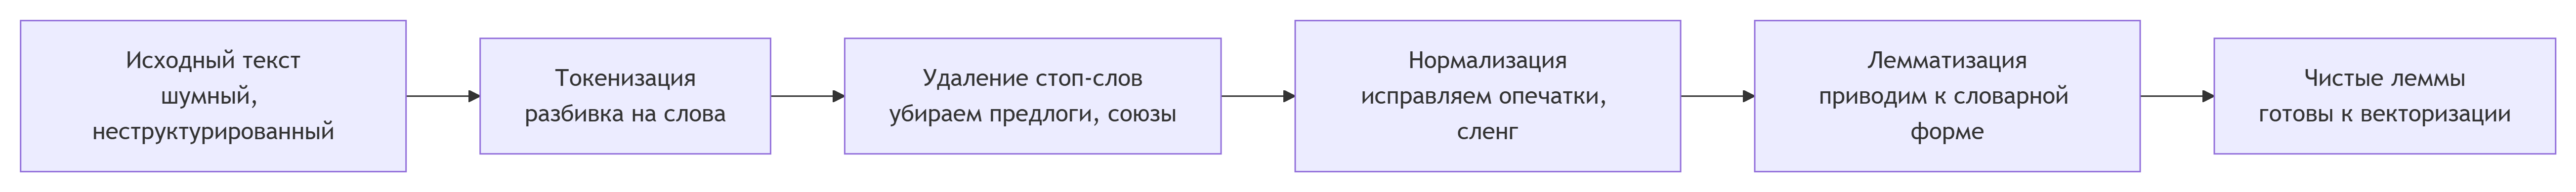



## 5. ПРЕДСТАВЛЕНИЕ ТЕКСТА: ОТ СЛОВ К ЧИСЛАМ

Очищенный текст всё ещё остаётся текстом. Компьютер работает с числами. Нам нужно **превратить слова в векторы чисел** — это называется **векторизацией**. Представьте, что каждое слово — это пациент, а его «числовой паспорт» — это набор цифр, по которым компьютер может его «узнать» и сравнить с другими словами.

Рассмотрим **четыре подхода**: от самого простого и интуитивного к сложным смысловым моделям. Каждый подход решает свою психологическую задачу.

---

### 5.1. One-Hot Encoding (Одно-горячее кодирование)

**Что это:** самый базовый способ представить слова в виде чисел. Мы создаём словарь всех уникальных слов в наших текстах. Затем каждое слово представляем как вектор длины = размер словаря, где на месте этого слова стоит **1**, а на всех остальных местах — **0**. Это похоже на список пациентов в клинике: у каждого пациента есть своя «карточка», где напротив его имени стоит галочка (1), а напротив всех остальных — пусто (0).

**Пример из психологии:**

Допустим, у нас есть словарь из 5 слов, которые встречаются в дневниках пациентов: `["тревога", "страх", "тоска", "надежда", "радость"]`.

Тогда:
- «тревога» → `[1, 0, 0, 0, 0]`
- «страх» → `[0, 1, 0, 0, 0]`
- «тоска» → `[0, 0, 1, 0, 0]`
- «надежда» → `[0, 0, 0, 1, 0]`
- «радость» → `[0, 0, 0, 0, 1]`

**Психологическая задача для One-Hot Encoding:**

Психолог ведёт базу данных, где каждому диагнозу присвоен свой код: F32.1 (депрессивный эпизод), F41.1 (генерализованное тревожное), F43.1 (ПТСР). Это классический one-hot: у каждого пациента есть «1» в графе своего диагноза и «0» во всех остальных. Так компьютер может быстро классифицировать пациентов по группам.

**Плюсы:**
- Предельная простота и наглядность.
- Не требует никаких вычислений — просто таблица соответствий.

**Минусы (их много, и это важно понять):**
1. **Огромная размерность.** Если в дневниках 10 000 уникальных слов, каждое слово станет вектором длины 10 000. Это неэффективно.
2. **Все слова равны.** Расстояние между «тревога» и «радость» такое же, как между «тревога» и «страх». Компьютер не знает, что одни слова ближе по смыслу.
3. **Нет учёта контекста.** Слово всегда кодируется одинаково, независимо от того, в каком предложении оно стоит.
4. **Потеря порядка.** Если мы кодируем целый текст как набор one-hot векторов, мы теряем последовательность слов.

**Вывод для психолога:** One-hot хорош для **категориальных переменных** (пол, диагноз, тип терапии), но совершенно не подходит для анализа смысла текста.

---

### 5.2. Мешок слов (Bag of Words, BoW)

**Что это:** следующий уровень. Мы не кодируем каждое слово отдельно, а считаем, **сколько раз каждое слово встретилось в тексте**. Текст становится вектором, где каждая позиция — это слово из общего словаря, а значение — его частота в этом тексте [2].

**Пример из психологии (расширенный, с реальными записями):**

Допустим, у нас есть 3 дневниковые записи пациентов:
1. *«я чувствую тревогу»*
2. *«тревога проходит, но остаётся страх»*
3. *«я чувствую усталость и страх»*

**Шаг 1.** Строим общий словарь всех уникальных слов (знаки препинания и стоп-слова удалены):
`["я", "чувствую", "тревогу", "проходит", "но", "остаётся", "страх", "усталость", "и"]` — всего 9 слов.

**Шаг 2.** Считаем частоту каждого слова в каждом тексте:

| Слова → Тексты ↓ | я | чувствую | тревогу | проходит | но | остаётся | страх | усталость | и |
|---|---|---|---|---|---|---|---|---|---|
| Текст 1 | 1 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 0 |
| Текст 2 | 0 | 0 | 1 | 1 | 1 | 1 | 1 | 0 | 0 |
| Текст 3 | 1 | 1 | 0 | 0 | 0 | 0 | 1 | 1 | 1 |

**Числовые векторы:**
- Текст 1 → `[1, 1, 1, 0, 0, 0, 0, 0, 0]`
- Текст 2 → `[0, 0, 1, 1, 1, 1, 1, 0, 0]`
- Текст 3 → `[1, 1, 0, 0, 0, 0, 1, 1, 1]`

**Психологическая задача для BoW:**

Психолог ведёт групповую терапию и просит пациентов каждый день писать одно предложение о своём состоянии. За месяц накапливается 30 текстов. Психолог хочет быстро понять:
- Какие темы доминируют? (облако тегов).
- У каких пациентов чаще встречаются слова, связанные со страхом, тревогой или безнадёжностью?

BoW позволяет посчитать частоты и построить облако тегов — визуальное отображение, где самые частые слова показаны самым крупным шрифтом.

**Пример облака тегов** (гипотетическое):
- Если в дневниках группы чаще всего встречаются слова *«тревога»*, *«сон»*, *«работа»*, *«страх»*, психолог видит, что основные проблемы группы связаны с тревогой и профессиональным стрессом.
- Если у конкретного пациента доминируют *«смерть»*, *«бессмысленно»*, *«устал»* — это сигнал для индивидуальной консультации.

**Плюсы:** простота, интуитивность, быстрота расчёта.

**Минусы:**
- **Потеря порядка слов.** *«я боюсь темноты»* и *«темноты боюсь я»* дадут одинаковый вектор.
- **Огромная размерность.** При 10 000 уникальных слов каждый текст — это вектор из 10 000 чисел, большинство из которых — нули (разреженная матрица).
- **Все слова равны.** Слово «я» и «суицид» имеют одинаковый вес, хотя их клиническая значимость совершенно разная.

---

### 5.3. TF-IDF (Term Frequency — Inverse Document Frequency)

**Что это:** улучшенная версия мешка слов. Она даёт **вес** словам на основе двух факторов [3]:
- **TF (Term Frequency):** чем чаще слово встречается в этом тексте, тем выше вес.
- **IDF (Inverse Document Frequency):** чем реже слово встречается **во всех текстах**, тем выше вес (потому что редкое слово более уникально и информативно).

**Формула (простыми словами):**  
`Вес слова = (сколько раз слово в этом тексте) × (логарифм от общего числа текстов / число текстов, где это слово есть)`

**Пример из психологии (конкретный, с расчётами):**

Возьмём 100 дневниковых записей пациентов. У нас есть два слова:
- **«я»** — встречается в 98 записях из 100.
- **«суицид»** — встречается только в 5 записях из 100.

Вычисляем IDF (упрощённо):
- Для «я»: log(100 / 98) ≈ log(1.02) ≈ 0.02 → очень маленький вес.
- Для «суицид»: log(100 / 5) = log(20) ≈ 1.30 → большой вес.

Если в тексте пациента слово «суицид» встречается 2 раза, а слово «я» — 10 раз, то вклад «суицида» в общий вектор будет значительно выше, несмотря на меньшую частоту.

**Конкретный пример с тремя текстами:**

Возьмём те же 3 текста, что в примере с BoW:
1. *«я чувствую тревогу»*
2. *«тревога проходит, но остаётся страх»*
3. *«я чувствую усталость и страх»*

**Считаем TF-IDF для каждого слова в каждом тексте:**

| Слово | TF (Текст 1) | TF (Текст 2) | TF (Текст 3) | IDF (log 3/число_текстов_со_словом) | TF-IDF (Текст 1) | TF-IDF (Текст 2) | TF-IDF (Текст 3) |
|---|---|---|---|---|---|---|---|
| я | 1 | 0 | 1 | log(3/2) ≈ 0.18 | 0.18 | 0 | 0.18 |
| чувствую | 1 | 0 | 1 | log(3/2) ≈ 0.18 | 0.18 | 0 | 0.18 |
| тревогу | 1 | 1 | 0 | log(3/2) ≈ 0.18 | 0.18 | 0.18 | 0 |
| проходит | 0 | 1 | 0 | log(3/1) ≈ 0.48 | 0 | 0.48 | 0 |
| но | 0 | 1 | 0 | log(3/1) ≈ 0.48 | 0 | 0.48 | 0 |
| остаётся | 0 | 1 | 0 | log(3/1) ≈ 0.48 | 0 | 0.48 | 0 |
| страх | 0 | 1 | 1 | log(3/2) ≈ 0.18 | 0 | 0.18 | 0.18 |
| усталость | 0 | 0 | 1 | log(3/1) ≈ 0.48 | 0 | 0 | 0.48 |
| и | 0 | 0 | 1 | log(3/1) ≈ 0.48 | 0 | 0 | 0.48 |

**Что мы видим:** слова, уникальные для одного текста («проходит», «но», «остаётся» в Тексте 2; «усталость», «и» в Тексте 3), получили **более высокий вес**. Общие слова («я», «чувствую», «тревога») — более низкий.

**Психологическая задача для TF-IDF (конкретная):**

Психолог ведёт **50 пациентов** и хочет выявить тех, у кого в языке появляются слова-маркеры суицидального риска: *«смерть»*, *«бессмысленно»*, *«устал жить»*, *«не хочу»*, *«конец»*.

Эти слова редкие — они встречаются только у 2–3 пациентов из 50. В обычном BoW они «теряются» на фоне частотных слов («я», «мой», «день»). TF-IDF **поднимает** эти редкие, но клинически значимые слова вверх, делая их заметными.

**Пример из практики:**
- У пациента А. в дневнике 20 раз встречается «я» и 2 раза «смерть». BoW даст одинаковый «вклад» этим словам? Нет, в BoW «я» будет иметь вес 20, а «смерть» — 2. TF-IDF скорректирует: «я» получит очень маленький множитель (IDF ≈ 0.02), а «смерть» — большой (IDF ≈ 1.30). Итоговый вклад «смерти» станет сопоставимым или даже большим, чем у «я».

**Вывод для психолога:** TF-IDF помогает **не упустить редкие, но важные сигналы**. Это как если бы психолог в группе из 50 пациентов специально искал тех, у кого появляются тревожные слова, даже если они звучат редко.

---

### 5.4. Векторные эмбеддинги (Word Embeddings)

**Что это:** следующий уровень сложности. Вместо того чтобы просто считать частоты, эмбеддинги учат компьютер **понимать смысл слов**, опираясь на их контекст. Слова с похожим значением получают похожие векторы [3].

**Ключевая идея:** *«Скажи мне, с кем ты дружишь, и я скажу, кто ты»* — для слов: значение слова определяется по словам, которые часто встречаются рядом с ним.

**Примеры эмбеддингов:**
- **Word2Vec**, **GloVe**, **FastText** — классические модели, где каждое слово получает фиксированный вектор (например, 300 чисел).
- **BERT**, **GPT** — современные модели, которые дают эмбеддинги уже с учётом контекста предложения (одно слово может иметь разные векторы в разных предложениях) [2].

**Пример из психологии (конкретный):**

В пространстве эмбеддингов (упрощённо, в 2D):
- Вектор слова **«тревога»** будет близок к векторам **«страх»**, **«беспокойство»**, **«паника»**.
- Вектор слова **«депрессия»** будет близок к **«тоска»**, **«апатия»**, **«безнадёжность»**.
- Расстояние между «тревога» и «страх» будет **маленьким**.
- Расстояние между «тревога» и «радость» будет **большим**.

**Что это даёт психологу?**

1. **Измерение семантической близости.** Можно количественно оценить, насколько язык пациента близок к «языку депрессии». Если пациент часто использует слова из кластера *«тоска, пустота, бессмысленно, устал»*, эмбеддинги покажут, что его язык «семантически близок» к депрессивному профилю.

2. **Отслеживание динамики в терапии.** Если в начале терапии язык пациента был близок к кластеру *«безнадёжность, страх, боль»*, а через 3 месяца появились слова *«надежда, будущее, радость, энергия»* — эмбеддинги могут измерить **семантический сдвиг**. Компьютер вычислит, насколько «уменьшилось расстояние» между языком пациента и кластером депрессии, и «увеличилось» расстояние до кластера благополучия.

3. **Выявление скрытых ассоциаций.** Например, у пациента с травмой в анамнезе слово *«мать»* может быть семантически близко к *«боль»* и *«страх»* (в отличие от здоровых людей, у которых *«мать»* ближе к *«тепло»* и *«забота»*). Эмбеддинги позволяют увидеть эти скрытые связи.

**Конкретный пример из исследования:**

В одном из экспериментов исследователи обучили модель Word2Vec на текстах пациентов с депрессией и здоровых людей. Оказалось, что у пациентов с депрессией слова *«будущее»* и *«надежда»* были **семантически дальше** от *«я»*, чем у здоровых. То есть депрессивные пациенты *ментально* воспринимали будущее как нечто отдалённое от себя — и это было измерено численно! [7]

**Плюсы:**
- Учитывают смысл, а не только частоту.
- Позволяют измерять семантические расстояния.
- Могут находить скрытые ассоциации.

**Минусы:**
- Требуют больших объёмов текста для обучения (миллионы слов).
- Чёрный ящик — сложно объяснить, почему слово получило именно такой вектор.
- Требуют вычислительных ресурсов.

**Важно для студентов:** не нужно запоминать формулы эмбеддингов. Достаточно понять **принцип**: числа могут отражать **смысл**, а не только частоту. Это как если бы мы могли измерить «эмоциональное расстояние» между словами пациента.

---

### 5.5. Сводная таблица: какой метод когда использовать

| Метод | Что делает | Когда использовать в психологии | Плюсы | Минусы |
|-------|-----------|--------------------------------|-------|--------|
| **One-Hot Encoding** | Каждое слово — уникальный вектор с одной единицей | Для категориальных данных: пол, диагноз, тип терапии | Простота, наглядность | Огромная размерность, все слова равны |
| **Bag of Words** | Считает частоту слов в тексте | Быстрый тематический анализ, облако тегов | Простота, интуитивность | Потеря порядка, все слова равны |
| **TF-IDF** | Взвешивает слова по редкости | Выявление редких маркеров (суицидальный риск, специфические симптомы) | Находит редкие, но важные сигналы | Потеря порядка, не учитывает смысл |
| **Word Embeddings** | Учит смысл из контекста | Отслеживание динамики, семантический анализ, скрытые ассоциации | Учитывает смысл, измеряет расстояния | Требует много данных, чёрный ящик |

**Визуализация:** четыре уровня сложности с психологическими задачами.


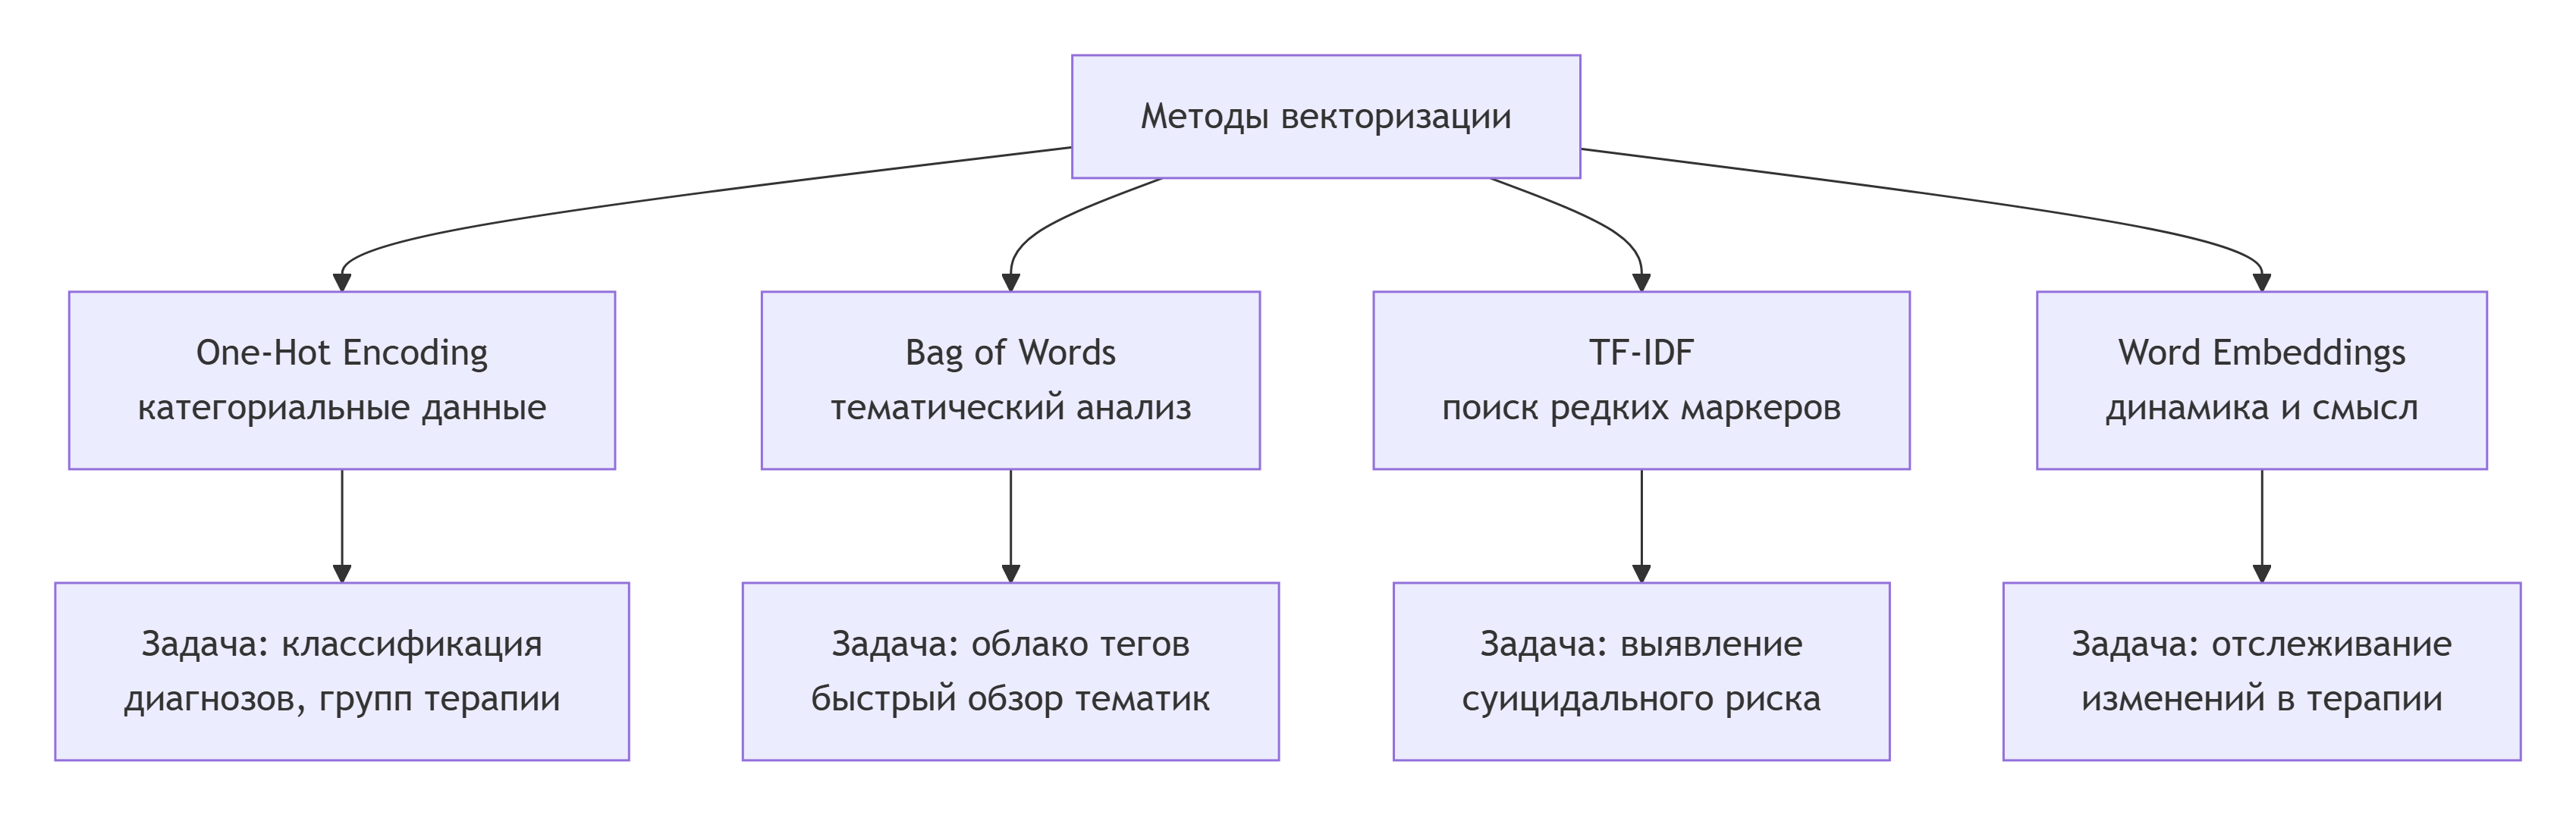



**Резюме для психолога:**

- **One-Hot** — для «ярлыков» (диагноз, пол).
- **BoW** — для первого, быстрого взгляда на тексты.
- **TF-IDF** — когда нужно не упустить редкие, но важные сигналы.
- **Эмбеддинги** — для глубокого понимания смысла, динамики и скрытых связей.

**Каждый метод — это инструмент для своей задачи.** Психолог не должен использовать отвёртку как молоток. Выбор метода зависит от того, **какой вопрос мы задаём данным**.



## 6. ОСОБЕННОСТИ РУССКОГО ЯЗЫКА В NLP

**Почему это отдельная тема:** большая часть NLP-инструментов разработана для английского языка [2]. Русский язык сложнее для автоматической обработки. Нужно понимать эти сложности, чтобы не переоценивать возможности готовых решений. Помните наш пример очистки текста из раздела 4? *«севодня ваще сил нет»*. Если бы мы просто скормили этот текст английской модели, она бы не поняла ни «севодня», ни «ваще», ни грамматическую конструкцию. Поэтому русский язык требует особого подхода.

Рассмотрим шесть ключевых вызовов — и то, как с ними справляются современные NLP-системы.

---

**1. Свободный порядок слов**

В английском языке порядок слов строго фиксирован: подлежащее → сказуемое → дополнение (*"I love you"*). В русском — почти любое сочетание допустимо:
- *«Я люблю тебя»*
- *«Тебя я люблю»*
- *«Люблю тебя я»*

Смысл один и тот же, но структура разная. Для моделей, которые учитывают порядок слов (например, трансформеры вроде BERT), это дополнительная сложность: модель должна научиться *не привязываться* к позиции слова в предложении.

**Пример из практики пациента:**
> *«Сегодня я совсем не могу. Совсем не могу я сегодня. Не могу я сегодня совсем.»*

Все три фразы говорят об одном: апатия, отсутствие сил. Но для модели, обученной на английском, первая фраза будет выглядеть "правильно", а вторая и третья — "странными". Хорошая русская модель должна понимать, что все три варианта означают одно и то же.

---

**2. Богатая морфология**

Одно слово может иметь десятки форм: падежи (6), числа (2), роды (3), времена, склонения, спряжения [4].
- Существительное *«сила»*: силы, силе, силу, силой, о силе, сил, силам, силами.
- Глагол *«бояться»*: боюсь, боишься, боится, боимся, боитесь, боятся, боялся, боялась, боялось, боялись.

**Что это значит для анализа:** словарь может разрастись в разы. Если мы не приведём все формы к одному корню, компьютер будет считать *«страх»*, *«страха»*, *«страху»* и *«страхом»* разными словами — и не сможет увидеть, что пациент говорит об одном и том же.

**Поэтому лемматизация для русского — не опция, а обязательный этап.**

**Пример из практики пациента:**
В дневнике пациента встречаются фразы:
- *«меня мучает страх»*
- *«я боюсь»*
- *«страшно»*
- *«испуг»*

Без лемматизации компьютер увидит 4 разных слова. С лемматизацией — все они сведутся к корням: *«страх»*, *«бояться»*, *«страшно»*, *«испуг»* — и компьютер поймёт, что тема страха доминирует в тексте.

---

**3. Сложное словообразование**

Приставки, суффиксы, постфиксы сильно меняют значение слова, но сохраняют общий корень. Модель должна научиться "видеть" этот корень:
- *«Тревога»* → *«тревожность»* (качество) → *«тревожиться»* (процесс) → *«встревоженный»* (состояние) → *«тревожно»* (наречие).

Все эти слова связаны с одним концептом — тревогой. Хорошая модель должна это понимать.

**Пример из практики пациента:**
> *«Я чувствую тревогу. Всё время тревожусь. Постоянно тревожные мысли. Живу в тревожном состоянии.»*

Для психолога очевидно: пациент говорит об одной проблеме. Для компьютера без нормализации — это 4 разных слова с разными корнями. Лемматизация или стемминг решают эту проблему.

---

**4. Сленг и неформальная лексика**

В психологических текстах — особенно у подростков и в интернет-общении — много разговорных и экспрессивных форм:
- «пздц» (сильное эмоциональное потрясение)
- «жёстко» (интенсивность переживания)
- «капец» (крайняя степень)
- «триггер» (психологический триггер, уже вошёл в обиход)
- «овертонк» (перебор, чрезмерность)

Стандартные словари их не знают. Если модель встретит «пздц», она может просто проигнорировать это слово или неверно интерпретировать. Нужно либо расширять словари вручную, либо использовать модели, которые умеют работать с редкими и нестандартными словами (например, **FastText** разбивает слова на подслова — части слова, которые помогают угадать значение даже для неизвестного слова) [3].

**Пример из практики пациента (подросток):**
> *«он меня опять затриггерил, я в ауте, капец, как же всё задолбало»*

Без нормализации:
- «затриггерил» → модель не знает этого слова.
- «ауте» → не знает.
- «капец» → не знает.
- «задолбало» → не знает (или знает как грубое слово, но не понимает эмоционального контекста).

С нормализацией и сленг-словарём:
- «затриггерил» → «запустил триггер» → модель понимает, что речь о психологической реакции.
- «в ауте» → «растерян» → модель понимает состояние.
- «капец» → «очень плохо» → усилитель эмоции.
- «задолбало» → «устало» → маркер эмоционального истощения.

---

**5. Отсутствие качественных, открытых корпусов психологических текстов на русском**

Для обучения моделей нужны большие размеченные корпуса — например, 10 000 дневниковых записей с диагностическими метками (депрессия, тревога, здоровые). На русском языке таких корпусов значительно меньше, чем на английском [7].

**Что это значит на практике:**
- Готовые английские модели (например, основанные на BERT) могут давать ошибки на русском языке.
- Если психолог захочет использовать модель для анализа русскоязычных текстов, ему нужно либо:
  - дообучать английскую модель на русских текстах (сложно),
  - использовать русскоязычные модели (например, ruBERT, DeepPavlov),
  - собирать свои данные и обучать модель с нуля (ещё сложнее).

**Позитивные примеры:** разработки ТГУ и НГУ (упоминались в Лекции 1) показывают, что адаптивные модели для русского языка уже создаются и дают хорошие результаты [1]. Но таких моделей всё ещё мало.

---

**6. Учёт культурного контекста**

Одно и то же слово может иметь разный эмоциональный оттенок в разных культурах [5].

**Ключевой пример:** слово *«тоска»*.
- В русском языке — это глубокое, экзистенциальное переживание, смесь печали, апатии и безнадёжности.
- В английском языке ближайший перевод — *"melancholy"* (меланхолия) или *"yearning"* (тоска по чему-то), но ни один из них не передаёт всю глубину русского *«тоска»*.

**Что будет, если модель обучена на английских текстах?**
- Если пациент напишет *«меня одолевает тоска»*, модель может перевести это как *"melancholy"* и интерпретировать как лёгкую грусть.
- На самом деле, в русском контексте это может быть симптомом депрессивного эпизода.

**Другой пример:** слово *«надоело»*.
- В русском языке это может означать как лёгкое раздражение, так и глубокое истощение.
- В английском *"fed up"* — обычно более лёгкое состояние.
- Модель, обученная на английских текстах, может недооценить тяжесть состояния пациента.

**Вывод:** при работе с русскоязычными пациентами критически важно использовать модели, обученные именно на русскоязычных текстах, а не переводить тексты на английский для анализа.

---

**Визуализация:** сложности русского языка в NLP.






> Add blockquote

> Add blockquote



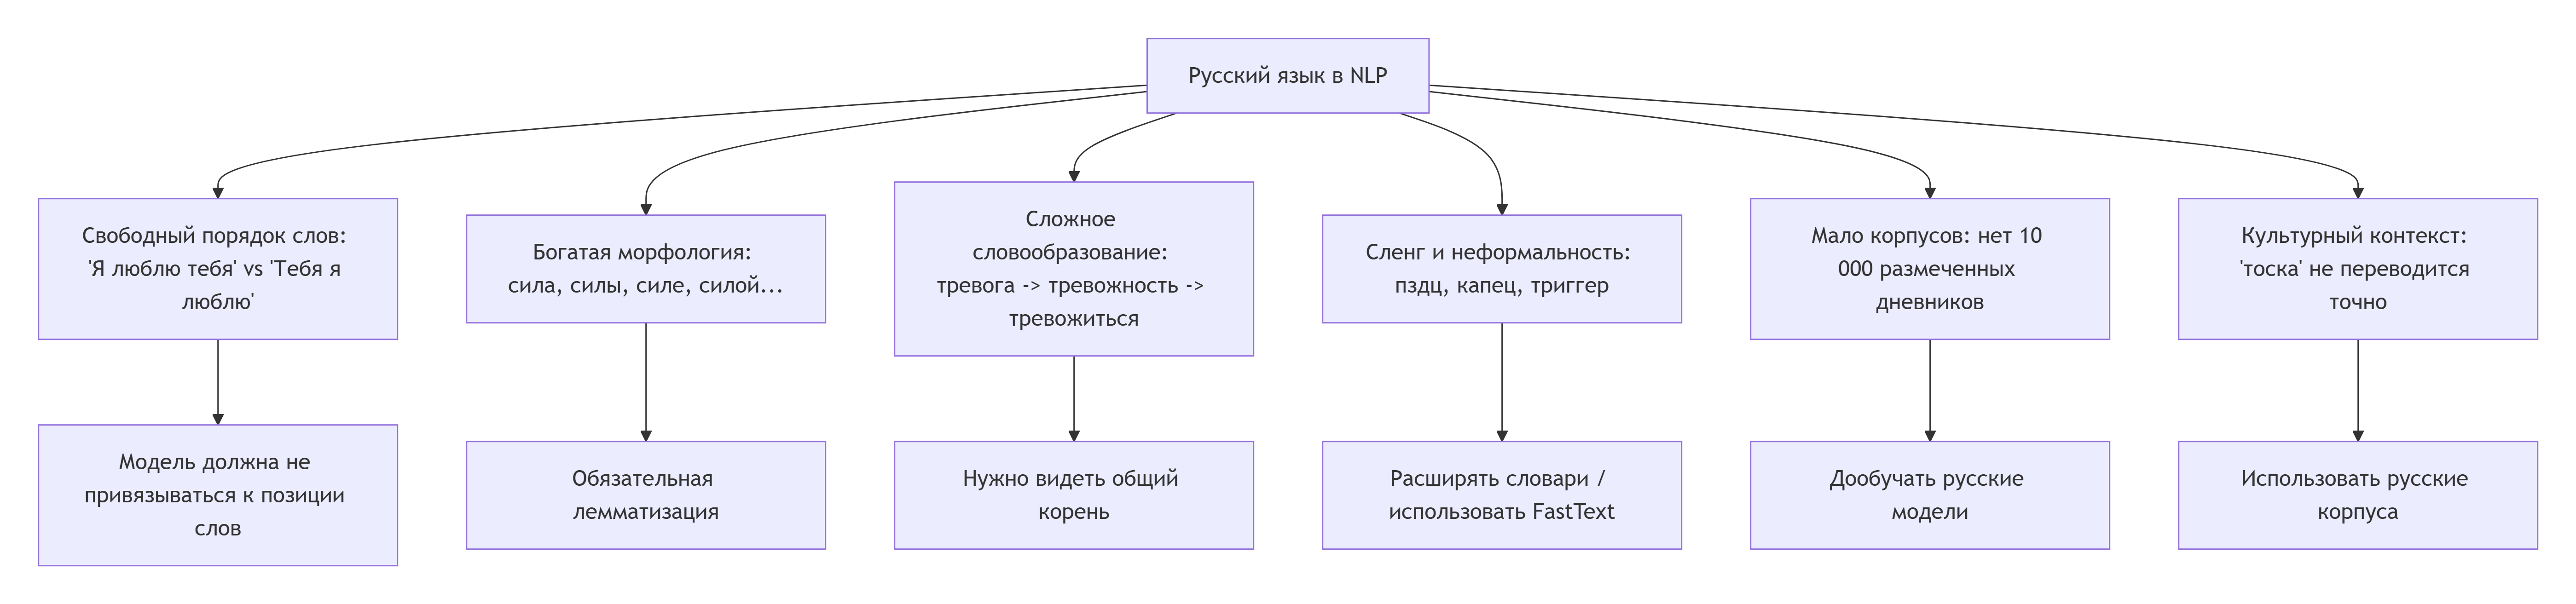


**Практический вывод для психолога:**

При работе с текстами русскоязычных пациентов нужно:
1. **Всегда использовать лемматизацию** (библиотеки `pymorphy2` или `mystem`) [6] — иначе компьютер не увидит связи между разными формами одного слова.
2. **Дополнять словари стоп-слов и сленга** — иначе модель пропустит важные эмоциональные маркеры.
3. **Критически относиться к моделям, которые не адаптированы под русский язык** — иначе можно получить неверную интерпретацию.
4. **Помнить о культурных нюансах** — слова могут значить больше, чем их буквальный перевод.





## 7. ПРАКТИЧЕСКОЕ УПРАЖНЕНИЕ НА ПАРЕ

> **Упражнение (сделайте самостоятельно за 3–5 минут):**
>
> Возьмите фразу из реальной дневниковой записи пациента:
>
> *«я севодня ваще не хочу ничево»*
>
> Выполните все этапы очистки текста **вручную**, заполняя таблицу:

| Этап | Результат | Ваш ответ |
|------|-----------|-----------|
| **Исходный текст** | `«я севодня ваще не хочу ничево»` | — |
| **1. Токенизация** | Разбейте на слова и знаки | → |
| **2. Удаление стоп-слов** | Какие слова удалите? Оставите ли «не»? | → |
| **3. Нормализация** | Исправьте опечатки и сленг | → |
| **4. Лемматизация** | Приведите к словарной форме | → |

---

**Вопросы для размышления (обсуждение в парах):**

1. **Какие слова останутся в итоге?** Что они говорят о состоянии пациента?
2. **Что было бы, если бы мы удалили «не»?** Изменился бы диагностический смысл фразы?
3. **Как бы вы интерпретировали этот текст** как психолог? Какие маркеры вы видите?

**Примерные ожидаемые ответы (для преподавателя):**

| Этап | Результат | Пояснение |
|------|-----------|-----------|
| **Исходный текст** | `«я севодня ваще не хочу ничево»` | Живая речь с опечатками и сленгом |
| **1. Токенизация** | `["я", "севодня", "ваще", "не", "хочу", "ничево"]` | Без знаков препинания |
| **2. Удаление стоп-слов** | Если удаляем «я» и стандартные стоп-слова, но **оставляем «не»** (клинический контекст): `["севодня", "ваще", "не", "хочу", "ничево"]` | «Не» — маркер негативного мышления |
| **3. Нормализация** | `["сегодня", "вообще", "не", "хочу", "ничего"]` | Исправили опечатки и сленг |
| **4. Лемматизация** | `["сегодня", "вообще", "не", "хотеть", "ничего"]` | Привели к словарной форме |

**Интерпретация для психолога:**
- Остаются смысловые ядра: *сегодня, вообще, не, хотеть, ничего*.
- Пациент сообщает об **ангедонии** (отсутствии желаний) и **апатии** («вообще не хочу»).
- Если бы мы удалили «не», смысл изменился бы на противоположный («хочу»), и мы потеряли бы ключевой маркер депрессивного состояния.

---

## 8. ОБЗОРНЫЙ КОД ДЛЯ ДЕМОНСТРАЦИИ

> Код приведён **исключительно для иллюстрации логики**. Студентам не обязательно его запоминать; важно понять **последовательность шагов** и то, *что* получается на выходе.




In [ ]:
!pip install nltk pymorphy3 scikit-learn

# =============================================================
# ИНСТРУКЦИЯ ПО УСТАНОВКЕ ЗАВИСИМОСТЕЙ (перед запуском)
# =============================================================
# Откройте терминал (командную строку) и выполните:
#
#   pip install nltk pymorphy3 scikit-learn
#
# Если у вас несколько версий Python, используйте pip3:
#   pip3 install nltk pymorphy3 scikit-learn
#
# После установки библиотек запустите этот скрипт.
# =============================================================

import nltk
import pymorphy3
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Скачиваем стоп-слова для русского языка (делается один раз)
nltk.download('stopwords')
nltk.download('punkt_tab')
# ============================================================
# ЧАСТЬ 1. ОЧИСТКА ТЕКСТА (ПРЕПРОЦЕССИНГ)
# ============================================================

# Пример текста пациента (реалистичная запись с опечатками и сленгом)
text = "чё то я севодня вабще без сил, не магу встать с кровати"

# Шаг 1. Токенизация: разбиваем на отдельные слова и знаки
tokens = nltk.word_tokenize(text, language='russian')
print("Токены:", tokens)
# → ['чё', 'то', 'я', 'севодня', 'вабще', 'без', 'сил', ',', 'не', 'магу', 'встать', 'с', 'кровати']

# Шаг 2. Удаление стоп-слов: убираем малоинформативные слова
# ВАЖНО: в клиническом контексте мы оставляем "не" — маркер негативного мышления
stop_words = set(nltk.corpus.stopwords.words('russian'))
stop_words.discard("не")  # оставляем "не" специально
filtered = [word for word in tokens if word not in stop_words and word.isalpha()]
print("После удаления стоп-слов:", filtered)
# → ['чё', 'севодня', 'вабще', 'сил', 'не', 'магу', 'встать', 'кровати']

# Шаг 3. Лемматизация: приводим слова к словарной форме
# Используем pymorphy3 (исправлено с pymorphy2 на pymorphy3)
morph = pymorphy3.MorphAnalyzer()
lemmas = [morph.parse(word)[0].normal_form for word in filtered]
print("Леммы:", lemmas)
# → ['что', 'сегодня', 'вообще', 'сила', 'не', 'мочь', 'встать', 'кровать']

# ============================================================
# ЧАСТЬ 2. ВЕКТОРИЗАЦИЯ (ОТ СЛОВ К ЧИСЛАМ)
# ============================================================

# Три дневниковые записи пациентов для сравнения
docs = [
    "я чувствую тревогу",                    # Пациент 1
    "тревога проходит но остаётся страх",    # Пациент 2
    "я чувствую усталость и страх"           # Пациент 3
]

# Метод 1. Мешок слов (Bag of Words) — считаем частоты
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(docs)
print("\n--- Bag of Words ---")
print("Словарь:", list(vectorizer.get_feature_names_out()))
print("Матрица частот:\n", X_bow.toarray())
# → матрица 3×9, где каждая строка — текст, столбцы — слова

# Метод 2. TF-IDF — взвешиваем по важности (редкие слова получают больший вес)
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(docs)
print("\n--- TF-IDF ---")
print("Матрица TF-IDF:\n", X_tfidf.toarray())
# → те же размеры, но значения отражают важность слов


**Что важно понять из кода (пояснение для студентов):**

| Что мы видим | Что это значит для психолога |
|--------------|------------------------------|
| `Токены: ['чё', 'то', 'я', ...]` | Текст разбит на отдельные «кирпичики» — слова и знаки |
| `После удаления стоп-слов: ['чё', 'севодня', ...]` | Убраны предлоги и союзы, но **сохранено «не»** — маркер негативного мышления |
| `Леммы: ['что', 'сегодня', 'вообще', ...]` | Все слова приведены к словарной форме — теперь можно считать частоту |
| `Матрица частот: [[1,1,1,0,...]]` | Таблица, где строки — тексты, столбцы — слова, значения — сколько раз слово встретилось |
| `Матрица TF-IDF: [[0.2, 0.1, ...]]` | Таблица, где редкие слова (например, «усталость») получили **больший вес** |

**Главный вывод:** после всех преобразований текст пациента превращается в **таблицу чисел**. Эту таблицу можно:
- Подать на вход алгоритмам машинного обучения (например, для классификации депрессии [1]).
- Использовать для статистического анализа (как мы делали в Лекции 2).
- Визуализировать (например, построить тепловую карту частот).

---

## 9. ЗАКЛЮЧЕНИЕ

Резюмируем пройденный путь: от «живого», неструктурированного, шумного текста пациента к аккуратным числовым векторам, которые компьютер может анализировать.

**Основные этапы обработки:**




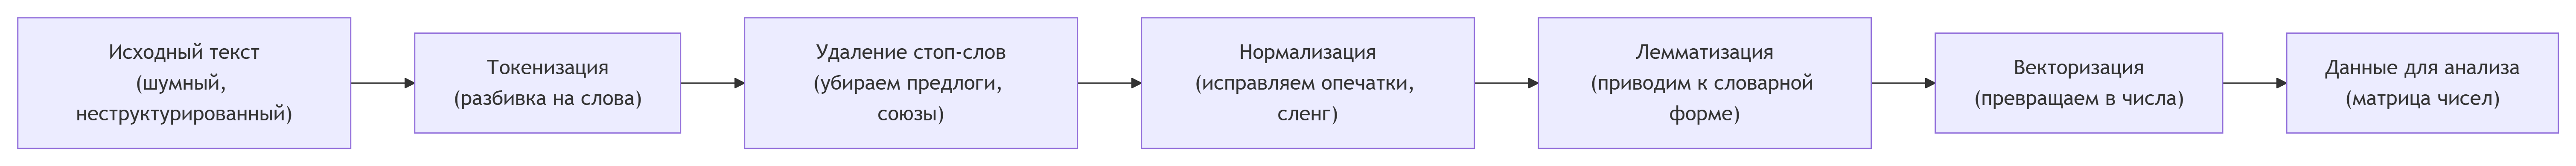


**Ключевые методы векторизации и их психологические задачи:**

| Метод | Что делает | Когда использовать |
|-------|-----------|---------------------|
| **One-Hot Encoding** | Каждое слово — уникальный вектор | Для категориальных данных (пол, диагноз) |
| **Bag of Words** | Считает частоту слов | Быстрый тематический анализ, облако тегов |
| **TF-IDF** | Взвешивает слова по редкости | Выявление редких маркеров (суицидальный риск) |
| **Word Embeddings** | Учит смысл из контекста | Отслеживание динамики, семантический анализ |

**Сложности русского языка:**
- Свободный порядок слов.
- Богатая морфология (требует лемматизации).
- Сленг и неформальная лексика (требует нормализации).
- Мало размеченных корпусов.
- Культурные нюансы («тоска» не переводится точно).

**Этический аспект:**
Автоматический анализ текста пациентов — мощный, но деликатный инструмент. Он требует:
- **Информированного согласия** пациента.
- **Прозрачности** алгоритма.
- **Осознания**, что алгоритмы могут ошибаться.
- **Интерпретация всегда остаётся за психологом** [7].

**Связь с предыдущими лекциями:**
- Из Лекции 1: именно такие векторизованные данные подаются на вход моделям ИИ.
- Из Лекции 2: эти данные можно описывать статистиками (среднее, медиана, стандартное отклонение).

**Главная мысль напоследок:**
> Компьютер не понимает текст — он только обрабатывает числа. Интерпретация смысла всегда остаётся задачей психолога. NLP — это инструмент, который помогает нам увидеть то, что мы могли бы пропустить. Но решающее слово — за человеком.

---

## 10. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ

1. Почему тексты пациентов считаются «шумными»? Приведите три примера такого шума.

2. Что такое токенизация и для чего она нужна при работе с дневниковыми записями?

3. Зачем удалять стоп-слова? Почему слово «не» может быть исключением в клиническом анализе?

4. Чем отличается стемминг от лемматизации? Какой подход больше подходит для русского языка и почему?

5. **Для каких психологических задач подходит One-Hot Encoding, а для каких — нет? Почему?**

6. Что такое «мешок слов» (Bag of Words)? Для какой психологической задачи он подходит?

7. В чём преимущество метода TF-IDF перед простым подсчётом частот? Приведите пример слова, которое получит высокий вес у пациента с суицидальными мыслями.

8. Что такое векторные эмбеддинги слов? Как они помогают компьютеру понимать смысл?

9. Назовите три особенности русского языка, усложняющих его обработку методами NLP.

10. Почему важно использовать модели, адаптированные для русского языка, а не переводить тексты на английский?

11. Как результаты NLP-анализа могут быть использованы психологом в реальной практике? Приведите два конкретных примера.

12. **Какие этические риски возникают при автоматическом анализе текстов пациентов? Как их можно минимизировать?**

---

## 11. ДОМАШНЕЕ ЗАДАНИЕ (срок — 2 недели)

**Часть 1. Очистка реального текста (2–3 страницы)**

Напишите или найдите в открытых источниках небольшой текст (10–15 предложений), имитирующий дневниковую запись пациента. Используйте все особенности: шум, опечатки, сленг, эмоциональность.

Проведите этапы очистки **вручную** (можно в таблице Word/Excel):

| Этап | Результат | Ваши действия |
|------|-----------|---------------|
| Исходный текст | (вставьте текст) | — |
| Токенизация | (разбейте на слова и знаки) | Перечислите токены |
| Удаление стоп-слов | (укажите, какие удалили) | Объясните, почему оставили/удалили «не» |
| Нормализация | (исправьте опечатки, сленг) | Покажите изменения |
| Лемматизация | (приведите к словарной форме) | Покажите леммы |

В конце напишите **рефлексию** (1 абзац):
*«Какие слова было сложно нормализовать и почему? Что могло бы быть неправильно понято компьютером?»*

---

**Часть 2. Представление текста в виде чисел (1–2 страницы)**

Возьмите три «очищенных» текста (можно из Части 1, сгенерируйте три варианта). На основе этих трёх текстов:

1. Составьте общий словарь уникальных слов.
2. Постройте матрицу «мешок слов» — вручную или в Excel/таблице (строки — тексты, столбцы — слова, значения — частоты).
3. Объясните, **какие слова получили бы высокий вес при использовании TF-IDF** и почему (без вычислений — качественно).

Пришлите таблицу и текстовое пояснение.

---

**Часть 3. Рефлексия о сложностях русского языка (1 страница)**

Напишите эссе на тему:
*«С какими сложностями я столкнулся(лась) при обработке текста на русском языке и как я их преодолевал(а)?»*

Опишите конкретные моменты, где язык пациента оказался «непослушным»:
- Какие слова было сложно нормализовать?
- Какие формы слов требовали особого внимания?
- Предложите, что могли бы сделать разработчики NLP-систем для лучшей работы с русской речью пациентов.

---

**Часть 4. Этика NLP (1 страница) — ОБЯЗАТЕЛЬНАЯ**

Представьте, что вы — руководитель психологического центра. Вам предлагают внедрить систему автоматического анализа дневниковых записей пациентов.

Составьте **краткий список этических требований** к такой системе:

1. Что должно быть в **информированном согласии** пациента?
2. Как **защищать данные** (хранение, доступ, анонимизация)?
3. Кто несёт **ответственность за ошибки** алгоритма?
4. Как **обеспечить прозрачность** работы системы для пациента?

---

## 12. ЛИТЕРАТУРА

1. Фироз, Н. и др. (2026). Мультимодальная нейросеть для диагностики депрессии на основе ЭЭГ и генетических маркеров. *Вестник ТГУ*, 15(3), 45–52.
2. Jurafsky, D., & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed.). Stanford University.
3. Goldberg, Y. (2017). *Neural Network Methods for Natural Language Processing*. Morgan & Claypool.
4. Плунгян, В. А. (2000). *Общая морфология: Введение в проблематику.* М.: Эдиториал УРСС.
5. Арутюнова, Н. Д. (1998). *Язык и мир человека.* М.: Языки русской культуры.
6. Официальная документация библиотек: NLTK (https://www.nltk.org), pymorphy2 (https://pymorphy2.readthedocs.io), spaCy (https://spacy.io).
7. Российский журнал когнитивной науки. (2025). *Применение NLP в клинической психологии: обзор современных подходов.* Том 12, № 2, 78–89.
8. Bender, E. M., Gebru, T., McMillan-Major, A., & Shmitchell, S. (2021). *On the Dangers of Stochastic Parrots: Can Language Models Be Too Big?* In Proceedings of FAccT '21. (Для углублённого изучения этических аспектов NLP).

---